In [12]:
!pip install -q kagglehub

In [2]:
!pip install clearml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.9 MB/s eta 0:00:00


In [4]:
#DO NOT RUN AGAIN
!clearml-init

ClearML SDK setup process

Please create new clearml credentials through the settings page in your `clearml-server` web app (e.g. http://localhost:8080//settings/workspace-configuration) 
Or create a free account at https://app.clear.ml/settings/workspace-configuration

In settings page, press "Create new credentials", then press "Copy to clipboard".

Paste copied configuration here:
api {     # Nikhila Sai Kuchimanchi's workspace     web_server: https://app.clear.ml/     api_server: https://api.clear.ml     files_server: https://files.clear.ml      credentials {         "access_key" = "V45E92E5YDRRGDASPNP0L3KEM2JMEY"         "secret_key" = "PwaGr272GheR61wTU2eAXfqGTTvfFF1vPq4RDA6pjHV6YdjXbAxvMODYVhavNEGCC8Q"     } }
Detected credentials key="V45E92E5YDRRGDASPNP0L3KEM2JMEY" secret="PwaG***"

ClearML Hosts configuration:
Web App: https://app.clear.ml/
API: https://api.clear.ml
File Store: https://files.clear.ml

Verifying credentials ...
Credentials verified!

New configuration stored i

In [7]:
import os
os.environ["CLEARML_CONFIG_FILE"] = "/root/clearml.conf"

In [9]:
import os

os.environ["CLEARML_API_ACCESS_KEY"] = "V45E92E5YDRRGDASPNP0L3KEM2JMEY"
os.environ["CLEARML_API_SECRET_KEY"] = "PwaGr272GheR61wTU2eAXfqGTTvfFF1vPq4RDA6pjHV6YdjXbAxvMODYVhavNEGCC8Q"
os.environ["CLEARML_API_HOST"] = "https://api.clear.ml"
os.environ["CLEARML_WEB_HOST"] = "https://app.clear.ml"
os.environ["CLEARML_FILES_HOST"] = "https://files.clear.ml"

In [10]:
from clearml import Task

task = Task.init(
    project_name="House Price Prediction",
    task_name="LightGBM Regression Experiment"
)

ClearML Task: created new task id=8eea06772d0a402f9d575baf175f065a


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


2026-04-20 21:45:21,837 - clearml.Task - INFO - Storing jupyter notebook directly as code
ClearML results page: https://app.clear.ml/projects/a370c1e518bf4f499010f5d37308b4ae/experiments/8eea06772d0a402f9d575baf175f065a/output/log
2026-04-20 21:45:25,519 - clearml.resource_monitor - WARNING - Could not fetch GPU stats: NVML Shared Library Not Found
ClearML results page: https://app.clear.ml/projects/a370c1e518bf4f499010f5d37308b4ae/experiments/8eea06772d0a402f9d575baf175f065a/output/log


In [14]:
import kagglehub

path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

task.connect_configuration({"dataset_path": path})

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'housing-prices-dataset' dataset.
Dataset downloaded to: /kaggle/input/housing-prices-dataset


In [15]:
import os

print(os.listdir(path))

['Housing.csv']


**Dataset Pre-Processing and Exploratory Data Analysis**

In [16]:
import pandas as pd

df = pd.read_csv(os.path.join(path, "Housing.csv"))
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


/usr/local/lib/python3.12/dist-packages/clearml/utilities/plotlympl/renderer.py:209: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



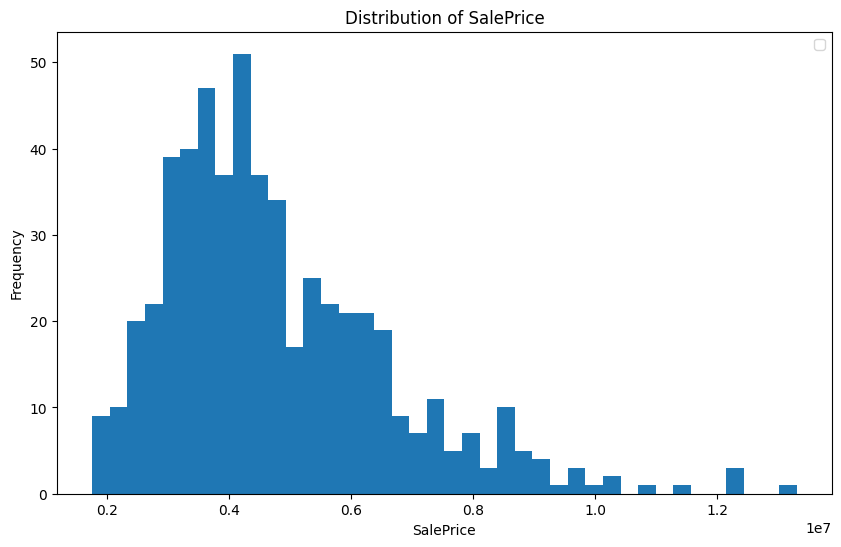

In [17]:
import matplotlib.pyplot as plt

# Plot distribution of price
plt.figure(figsize=(10,6))
plt.hist(df["price"], bins=40)
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()

In [18]:
# All rows where main road is yes
mainroad_yes = df[df['mainroad'] == 'no']
print(mainroad_yes)

       price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
143  5600000  4800         5          2        3       no        no      yes   
157  5495000  2817         4          2        2       no       yes      yes   
169  5250000  6540         4          2        2       no        no       no   
180  5215000  4500         4          2        1       no        no      yes   
182  5145000  3410         3          1        2       no        no       no   
..       ...   ...       ...        ...      ...      ...       ...      ...   
532  2135000  3000         2          1        1       no        no       no   
536  1960000  3420         5          1        2       no        no       no   
539  1855000  2990         2          1        1       no        no       no   
541  1767150  2400         3          1        1       no        no       no   
543  1750000  2910         3          1        1       no        no       no   

    hotwaterheating airconditioning  pa

In [19]:
# All rows where hot water is no
mainroad_yes = df[df['hotwaterheating'] == 'yes']
print(mainroad_yes)
print("Count:", len(mainroad_yes))

       price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
11   9681000   6000         4          3        2      yes       yes      yes   
13   9240000   3500         4          2        2      yes        no       no   
20   8750000   4320         3          1        2      yes        no      yes   
28   8400000   7950         5          2        2      yes        no      yes   
36   8043000   7482         3          2        3      yes        no       no   
66   6930000  13200         2          1        1      yes        no      yes   
74   6650000   4040         3          1        2      yes        no      yes   
75   6650000   4260         4          2        2      yes        no       no   
80   6629000   6000         3          1        2      yes        no       no   
84   6510000   3760         3          1        2      yes        no       no   
109  6090000   6615         4          2        2      yes       yes       no   
143  5600000   4800         

In [20]:
# Drop Hot Water Heating and Main Road columns as they don't significantly impact the price.
df = df.drop(columns=['hotwaterheating','mainroad'])
df.head()

,price,area,bedrooms,bathrooms,stories,guestroom,basement,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,no,yes,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,no,yes,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,2,no,furnished


In [21]:
df.shape

(545, 11)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   guestroom         545 non-null    object
 6   basement          545 non-null    object
 7   airconditioning   545 non-null    object
 8   parking           545 non-null    int64 
 9   prefarea          545 non-null    object
 10  furnishingstatus  545 non-null    object
dtypes: int64(6), object(5)
memory usage: 47.0+ KB


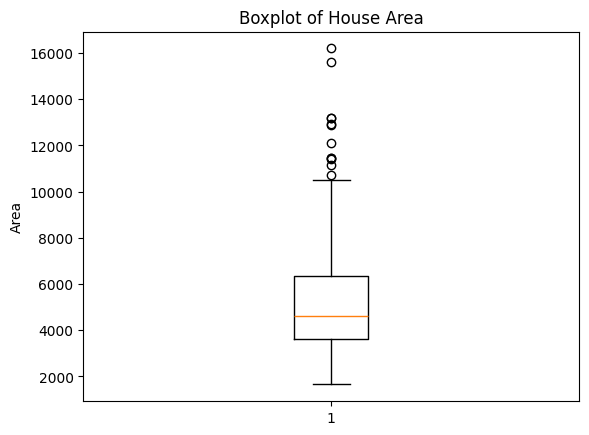

In [23]:
# Boxplot of Area
plt.boxplot(df['area'])
plt.title("Boxplot of House Area")
plt.ylabel("Area")
plt.show()

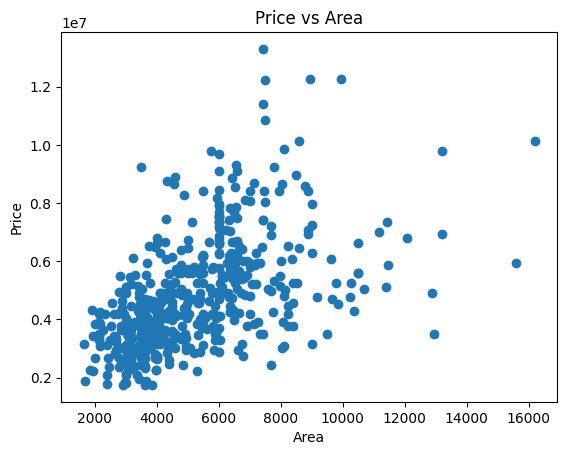

In [24]:
# Price vs Area
plt.scatter(df['area'], df['price'])
plt.title("Price vs Area")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

In [25]:
df = df.rename(columns={'area': 'area (sq ft)'})
df.head()

,price,area (sq ft),bedrooms,bathrooms,stories,guestroom,basement,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,no,yes,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,no,yes,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,2,no,furnished


In [26]:
# Minimums and Maximums of Columns
print("Column ranges (min, max):")
for col in df.columns:
    col_min = df[col].min()
    col_max = df[col].max()
    print(f"{col}: ({col_min}, {col_max})")

Column ranges (min, max):
price: (1750000, 13300000)
area (sq ft): (1650, 16200)
bedrooms: (1, 6)
bathrooms: (1, 4)
stories: (1, 4)
guestroom: (no, yes)
basement: (no, yes)
airconditioning: (no, yes)
parking: (0, 3)
prefarea: (no, yes)
furnishingstatus: (furnished, unfurnished)


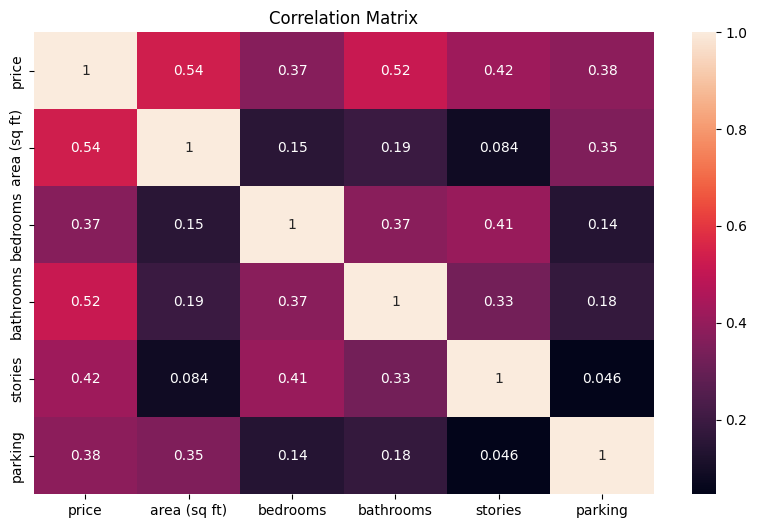

In [27]:
# Correlation Matrix
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

**Preprocessing Categorical Features**

In [28]:
from sklearn.preprocessing import LabelEncoder

# Make a copy to avoid modifying the original DataFrame directly
df_encoded = df.copy()

# Apply Label Encoding to binary categorical columns ('yes'/'no')
binary_cols = ['guestroom', 'basement', 'airconditioning', 'prefarea']
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({'yes': 1, 'no': 0})

# Apply One-Hot Encoding to 'furnishingstatus'
df_encoded = pd.get_dummies(df_encoded, columns=['furnishingstatus'], drop_first=True)

# Drop outliers
df_encoded = df_encoded[df_encoded['price'] < 12000000]
display(df_encoded.head())

,price,area (sq ft),bedrooms,bathrooms,stories,guestroom,basement,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
4,11410000,7420,4,1,2,1,1,1,2,0,False,False
5,10850000,7500,3,3,1,0,1,1,2,1,True,False
6,10150000,8580,4,3,4,0,0,1,2,1,True,False
7,10150000,16200,5,3,2,0,0,0,0,0,False,True
8,9870000,8100,4,1,2,1,1,1,2,1,False,False


**Splitting Data into Training and Testing Sets**


In [30]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (432, 11)
X_test shape: (109, 11)
y_train shape: (432,)
y_test shape: (109,)


**Hyperparameter Tuning for LightGBM**


In [31]:
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb

# Define the parameter grid to search for LightGBM
param_grid_lgbm = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 40],
    'max_depth': [5, 7, -1] # -1 means no limit on tree depth
}

# Initialize the LightGBM Regressor
lgbm = lgb.LGBMRegressor(objective='regression', random_state=42)

# Initialize GridSearchCV
grid_search_lgbm = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid_lgbm,
    cv=5, # 5-fold cross-validation
    scoring='neg_mean_squared_error',
    n_jobs=-1, # Use all available cores
    verbose=2
)

# Fit GridSearchCV to the training data
grid_search_lgbm.fit(X_train, y_train)

print("GridSearchCV for LightGBM completed. Best parameters found:")
print(grid_search_lgbm.best_params_)

# Get the best estimator
best_lgbm_regressor = grid_search_lgbm.best_estimator_
print("Best LightGBM Regressor model obtained.")

#log hyperparameters into clearML
task.connect(param_grid_lgbm)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 137
[LightGBM] [Info] Number of data points in the train set: 432, number of used features: 11
[LightGBM] [Info] Start training from score 4636566.990741
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

{'n_estimators': [100, 200, 300],
 'learning_rate': [0.01, 0.05, 0.1],
 'num_leaves': [20, 31, 40],
 'max_depth': [5, 7, -1]}

**Evaluate Tuned LightGBM Model**

Tuned LightGBM R-squared (R2): 0.5524
Tuned LightGBM Mean Absolute Error (MAE): 927913.07
Tuned LightGBM Mean Squared Error (MSE): 1788973406066.77
Tuned LightGBM Root Mean Squared Error (RMSE): 1337525.10
Tuned LightGBM Regression Accuracy (≈): 80.09%


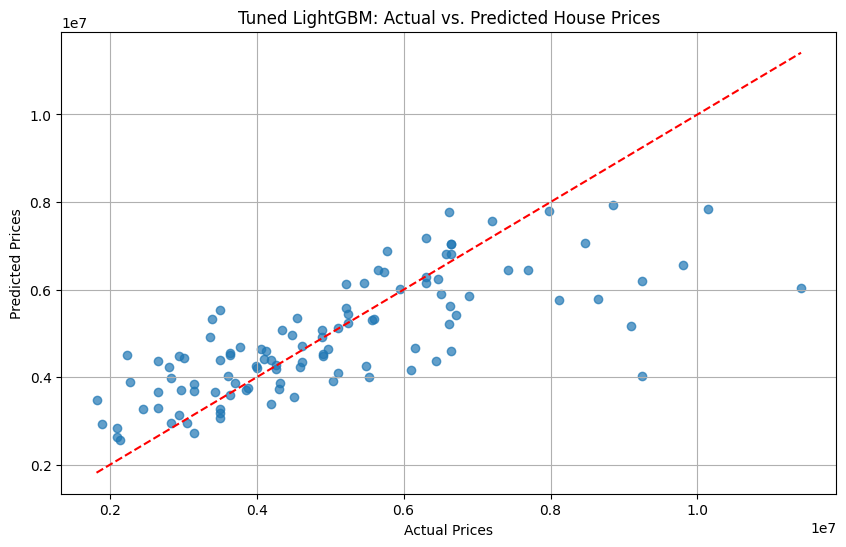

In [32]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Make predictions on the test set using the best estimator
y_pred_lgbm_tuned = best_lgbm_regressor.predict(X_test)

# Calculate evaluation metrics
r2_lgbm_tuned = r2_score(y_test, y_pred_lgbm_tuned)
mae_lgbm_tuned = mean_absolute_error(y_test, y_pred_lgbm_tuned)
mse_lgbm_tuned = mean_squared_error(y_test, y_pred_lgbm_tuned)
rmse_lgbm_tuned = np.sqrt(mse_lgbm_tuned)

# "Accuracy" for regression using Mean Absolute Percentage Error
mape_lgbm_tuned = np.mean(np.abs((y_test - y_pred_lgbm_tuned) / y_test)) * 100
accuracy_lgbm_tuned = 100 - mape_lgbm_tuned

print(f"Tuned LightGBM R-squared (R2): {r2_lgbm_tuned:.4f}")
print(f"Tuned LightGBM Mean Absolute Error (MAE): {mae_lgbm_tuned:.2f}")
print(f"Tuned LightGBM Mean Squared Error (MSE): {mse_lgbm_tuned:.2f}")
print(f"Tuned LightGBM Root Mean Squared Error (RMSE): {rmse_lgbm_tuned:.2f}")
print(f"Tuned LightGBM Regression Accuracy (≈): {accuracy_lgbm_tuned:.2f}%")

# Visualize predictions vs. actual values for the tuned model
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lgbm_tuned, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Tuned LightGBM: Actual vs. Predicted House Prices")
plt.grid(True)
plt.show()

**ClearML**

In [33]:
from clearml import Logger
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

logger = task.get_logger()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_list = []
mae_list = []
rmse_list = []
acc_list = []

for i, (train_idx, val_idx) in enumerate(kf.split(X)):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = best_lgbm_regressor
    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    r2 = r2_score(y_val, preds)
    mae = mean_absolute_error(y_val, preds)
    rmse = np.sqrt(mean_squared_error(y_val, preds))


    accuracy = r2

    r2_list.append(r2)
    mae_list.append(mae)
    rmse_list.append(rmse)
    acc_list.append(accuracy)

    # IMPORTANT: iteration = fold index
    logger.report_scalar("R2 Score", "Validation", value=r2, iteration=i)
    logger.report_scalar("MAE", "Validation", value=mae, iteration=i)
    logger.report_scalar("RMSE", "Validation", value=rmse, iteration=i)
    logger.report_scalar("Accuracy", "Validation", value=accuracy, iteration=i)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 137
[LightGBM] [Info] Number of data points in the train set: 432, number of used features: 11
[LightGBM] [Info] Start training from score 4636566.990741
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

In [ ]:
#Save and upload model onto clearML
import joblib

joblib.dump(best_lgbm_regressor, "model.pkl")

task.upload_artifact(
    name="trained_model",
    artifact_object="model.pkl"
)

**FastAPI — Real-Time Inference API**

In [ ]:
# Install API dependencies
!pip install -q fastapi uvicorn[standard] pyngrok nest-asyncio

In [ ]:
%%writefile app.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
import joblib, pandas as pd, time, logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

app = FastAPI(title="House Price Prediction API", version="1.0.0")

model = joblib.load("model.pkl")
logger.info("Model loaded successfully")

FEATURE_COLUMNS = [
    "area (sq ft)", "bedrooms", "bathrooms", "stories",
    "guestroom", "basement", "airconditioning", "prefarea", "parking",
    "furnishingstatus_semi-furnished", "furnishingstatus_unfurnished"
]

# ---------- schemas ----------
class HouseFeatures(BaseModel):
    area_sq_ft: float    = Field(..., gt=0)
    bedrooms: int        = Field(..., ge=0)
    bathrooms: int       = Field(..., ge=0)
    stories: int         = Field(..., ge=1)
    guestroom: int       = Field(..., ge=0, le=1)
    basement: int        = Field(..., ge=0, le=1)
    airconditioning: int = Field(..., ge=0, le=1)
    prefarea: int        = Field(..., ge=0, le=1)
    parking: int         = Field(..., ge=0)
    furnishingstatus_semi_furnished: int = Field(..., ge=0, le=1)
    furnishingstatus_unfurnished: int    = Field(..., ge=0, le=1)

class PredictionResponse(BaseModel):
    predicted_price: float
    latency_ms: float

class BatchRequest(BaseModel):
    houses: list[HouseFeatures]

class BatchResponse(BaseModel):
    predictions: list[float]
    count: int
    total_latency_ms: float
    avg_latency_ms: float

# ---------- helper ----------
def to_df(houses):
    rows = [{
        "area (sq ft)": h.area_sq_ft,
        "bedrooms": h.bedrooms,
        "bathrooms": h.bathrooms,
        "stories": h.stories,
        "guestroom": h.guestroom,
        "basement": h.basement,
        "airconditioning": h.airconditioning,
        "prefarea": h.prefarea,
        "parking": h.parking,
        "furnishingstatus_semi-furnished": h.furnishingstatus_semi_furnished,
        "furnishingstatus_unfurnished": h.furnishingstatus_unfurnished,
    } for h in houses]
    return pd.DataFrame(rows, columns=FEATURE_COLUMNS)

# ---------- endpoints ----------
@app.get("/health")
def health():
    return {"status": "ok", "model_loaded": model is not None}

@app.post("/predict", response_model=PredictionResponse)
def predict(house: HouseFeatures):
    start = time.perf_counter()
    try:
        price = float(model.predict(to_df([house]))[0])
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))
    latency_ms = (time.perf_counter() - start) * 1000
    logger.info(f"Single predict: ${price:,.0f}  latency={latency_ms:.2f}ms")
    return PredictionResponse(predicted_price=round(price, 2), latency_ms=round(latency_ms, 3))

@app.post("/predict/batch", response_model=BatchResponse)
def predict_batch(request: BatchRequest):
    start = time.perf_counter()
    try:
        prices = model.predict(to_df(request.houses)).tolist()
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))
    total_ms = (time.perf_counter() - start) * 1000
    avg_ms   = total_ms / len(request.houses)
    logger.info(f"Batch predict: {len(prices)} houses  total={total_ms:.2f}ms")
    return BatchResponse(
        predictions=[round(p, 2) for p in prices],
        count=len(prices),
        total_latency_ms=round(total_ms, 3),
        avg_latency_ms=round(avg_ms, 3)
    )

@app.get("/model/info")
def model_info():
    return {"model_type": type(model).__name__, "features": FEATURE_COLUMNS}


Overwriting app.py


In [ ]:
import nest_asyncio, uvicorn, threading, time as _time

nest_asyncio.apply()

def run_server():
    uvicorn.run('app:app', host='0.0.0.0', port=8000, log_level='warning')

thread = threading.Thread(target=run_server, daemon=True)
thread.start()
_time.sleep(2)
print('Server started on http://localhost:8000')
print('Swagger docs:  http://localhost:8000/docs')

Server started on http://localhost:8000
Swagger docs:  http://localhost:8000/docs


In [ ]:
import requests

resp = requests.get('http://localhost:8000/health')
print('Health:', resp.json())

Health: {'status': 'ok', 'model_loaded': True}


In [ ]:
import requests

payload = {
    'area_sq_ft': 7420, 'bedrooms': 4, 'bathrooms': 2, 'stories': 3,
    'guestroom': 0, 'basement': 0, 'airconditioning': 1, 'prefarea': 1,
    'parking': 2, 'furnishingstatus_semi_furnished': 0,
    'furnishingstatus_unfurnished': 0
}

resp   = requests.post('http://localhost:8000/predict', json=payload)
result = resp.json()
print(f"Predicted price  : ${result['predicted_price']:,.0f}")
print(f"Inference latency: {result['latency_ms']} ms")

Predicted price  : $8,240,139
Inference latency: 12.816 ms


In [ ]:
import requests

col_map = {
    'area (sq ft)': 'area_sq_ft',
    'furnishingstatus_semi-furnished': 'furnishingstatus_semi_furnished',
    'furnishingstatus_unfurnished':    'furnishingstatus_unfurnished'
}

batch_houses = []
for _, row in X_test.head(10).iterrows():
    house = {col_map.get(c, c): (float(v) if c == 'area (sq ft)' else int(v))
             for c, v in row.items()}
    batch_houses.append(house)

resp   = requests.post('http://localhost:8000/predict/batch', json={'houses': batch_houses})
result = resp.json()
print('Predictions  :', [f"${p:,.0f}" for p in result['predictions']])
print('Total latency:', result['total_latency_ms'], 'ms')
print('Avg per house:', result['avg_latency_ms'],   'ms')

Predictions  : ['$5,335,802', '$6,571,283', '$4,802,220', '$4,144,017', '$3,741,362', '$6,306,301', '$4,331,843', '$4,425,927', '$3,470,886', '$3,197,134']
Total latency: 9.574 ms
Avg per house: 0.957 ms


Requests    : 100
Mean latency: 22.73 ms
P50 latency : 21.04 ms
P95 latency : 43.63 ms
P99 latency : 52.62 ms
Max latency : 58.78 ms


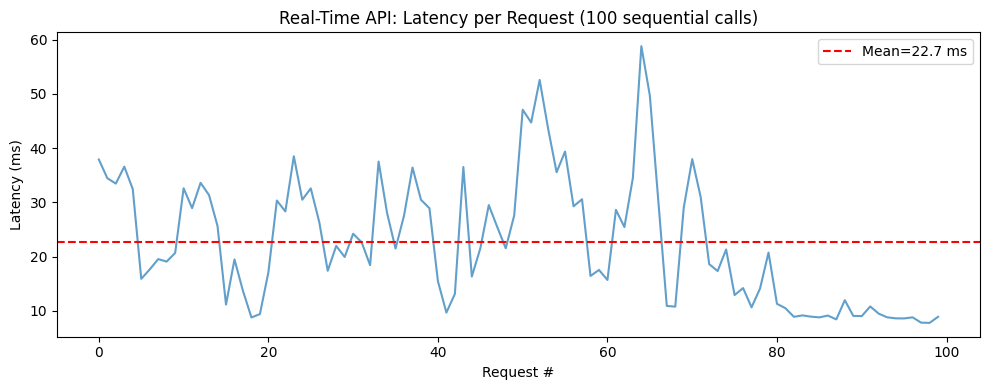

In [ ]:
import requests, time, numpy as np, matplotlib.pyplot as plt

N = 100
latencies = []

for _, row in X_test.head(N).iterrows():
    house = {
        'area_sq_ft':   float(row['area (sq ft)']),
        'bedrooms':     int(row['bedrooms']),
        'bathrooms':    int(row['bathrooms']),
        'stories':      int(row['stories']),
        'guestroom':    int(row['guestroom']),
        'basement':     int(row['basement']),
        'airconditioning': int(row['airconditioning']),
        'prefarea':     int(row['prefarea']),
        'parking':      int(row['parking']),
        'furnishingstatus_semi_furnished': int(row['furnishingstatus_semi-furnished']),
        'furnishingstatus_unfurnished':    int(row['furnishingstatus_unfurnished'])
    }
    t0 = time.perf_counter()
    requests.post('http://localhost:8000/predict', json=house)
    latencies.append((time.perf_counter() - t0) * 1000)

print(f'Requests    : {N}')
print(f'Mean latency: {np.mean(latencies):.2f} ms')
print(f'P50 latency : {np.percentile(latencies, 50):.2f} ms')
print(f'P95 latency : {np.percentile(latencies, 95):.2f} ms')
print(f'P99 latency : {np.percentile(latencies, 99):.2f} ms')
print(f'Max latency : {np.max(latencies):.2f} ms')

plt.figure(figsize=(10, 4))
plt.plot(latencies, alpha=0.7)
plt.axhline(np.mean(latencies), color='red', linestyle='--',
            label=f'Mean={np.mean(latencies):.1f} ms')
plt.xlabel('Request #')
plt.ylabel('Latency (ms)')
plt.title('Real-Time API: Latency per Request (100 sequential calls)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import os
os.listdir('/content')

['.config', 'sample_data']